In [2]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
path = '/home/usr/sc2Flow_lab/datasets/sciplex3_pre_2000.h5ad'
adata_ = sc.read_h5ad(path)

['Quisinostat (JNJ-26481585) 2HCl', 'Abexinostat (PCI-24781)', 'CUDC-907', 'Dacinostat', 'Givinostat (ITF2357)', 'M344', 'AR-42', 'Panobinostat (LBH589)', 'Pracinostat (SB939)', 'Resminostat', 'Trichostatin A (TSA)', 'Mocetinostat (MGCD0103)', 'CUDC-101', 'Belinostat (PXD101)']
颜色分配完成，共分配颜色数: 16
product_name
Panobinostat (LBH589)              1235
Quisinostat (JNJ-26481585) 2HCl    1195
Dacinostat                          735
Pracinostat (SB939)                 463
Abexinostat (PCI-24781)             406
AR-42                               395
Givinostat (ITF2357)                389
Belinostat (PXD101)                 383
Trichostatin A (TSA)                345
CUDC-907                            284
M344                                 90
Mocetinostat (MGCD0103)              37
CUDC-101                             30
Resminostat                          17
Name: count, dtype: int64
stopped at:  14


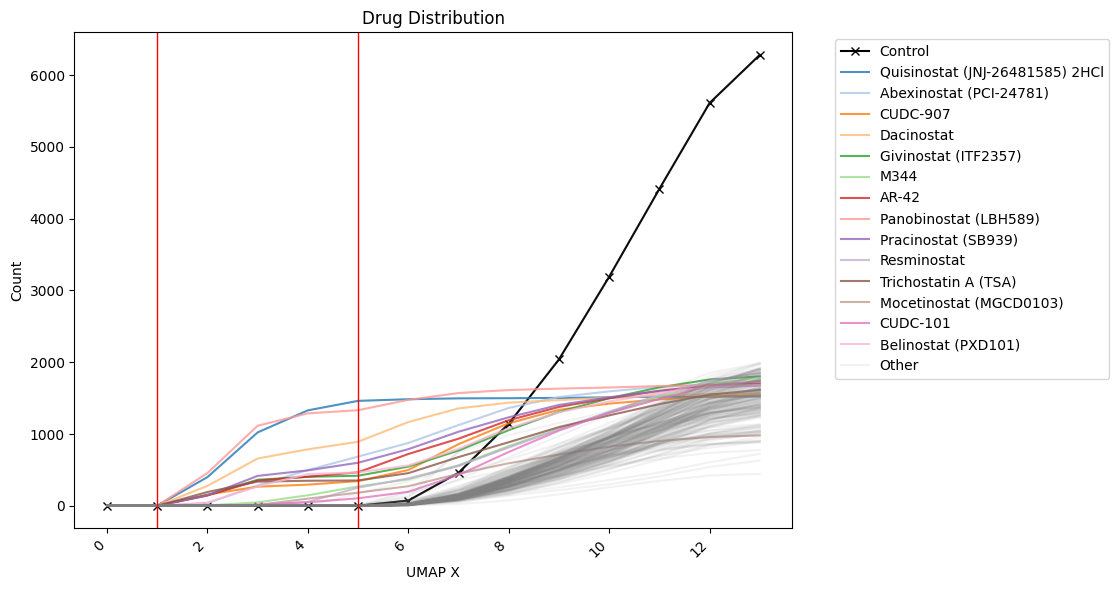

In [20]:

adata = adata_[adata_.obs['cell_type'] == 'MCF7'].copy()

check_name = 'product_name'
adata.obs[check_name] = adata.obs[check_name].astype('category')
umap_coords = adata.obsm['X_umap']
umap_x = umap_coords[:, 0]  # UMAP1
umap_y = umap_coords[:, 1]  # UMAP2

x_min = 0
x_max = 15
y_min = 0
y_max = 17
    

adata_ctrl = adata[adata.obs['control'] == 1].copy()
ctrl_umap_coords = adata_ctrl.obsm['X_umap']

ctrl_umap_x = ctrl_umap_coords[:,0]
ctrl_umap_y = ctrl_umap_coords[:,1]

ctrl_umap_x_min = ctrl_umap_x.min()
ctrl_umap_x_max = ctrl_umap_x.max()
# ctrl_umap_y_min = ctrl_umap_y.min()
# ctrl_umap_y_max = ctrl_umap_y.max()

x_max = ctrl_umap_x_max

selected_index = (umap_x < ctrl_umap_x_min-1)
select_obs = adata[selected_index].obs

selected_drug = list(set(select_obs[check_name].value_counts().index[select_obs[check_name].value_counts()>5]))
print(selected_drug)




# color plate setting
if len(selected_drug) <= 10:
    cmap = plt.get_cmap('tab10')
elif len(selected_drug) <= 20:
    cmap = plt.get_cmap('tab20') 
else:
    cmap = plt.get_cmap('gist_ncar')

global_color_map = {}

global_color_map['DMSO'] = 'black'
global_color_map['Other'] = 'gray'

num_drugs = len(selected_drug)
for i, drug in enumerate(selected_drug):
    if num_drugs <= 20:
        global_color_map[drug] = cmap(i)
    else:
        global_color_map[drug] = cmap(i / num_drugs)

print("colors:", len(global_color_map))

select_obs = select_obs[check_name][select_obs[check_name].isin(selected_drug)].cat.remove_unused_categories().copy()
print(select_obs.value_counts())
step = 1

all_drugs = adata.obs[check_name].cat.categories.tolist()
non_selected_drugs = [drug for drug in all_drugs if drug not in selected_drug]

selected_count_list = {}
non_selected_count_list = {}
DMSO_list = []

plt.figure(figsize=(12, 6))

current_x = x_min
for i in range(int((x_max - x_min) // step)):
    current_x = current_x + step
    x_index = np.where((umap_x > x_min) & (umap_x < current_x))
    y_index = np.where((umap_y > y_min) & (umap_y < y_max))
    common_indices = np.intersect1d(x_index, y_index)
    if (len(common_indices) == 0):
        print('stopped at: ', current_x)
        break
    select_obs = adata.obs.iloc[common_indices]
    value_counts = select_obs[check_name].value_counts()
    drug_counts_dict = value_counts.to_dict()
    
    for drug in selected_drug:
        if drug not in selected_count_list:
            selected_count_list[drug] = []
        selected_count_list[drug].append(drug_counts_dict.get(drug, 0))

    for drug in non_selected_drugs:
        if drug not in non_selected_count_list:
            non_selected_count_list[drug] = []
        non_selected_count_list[drug].append(drug_counts_dict.get(drug, 0))

    if check_name == 'product_name':
        DMSO_list.append(drug_counts_dict.get('DMSO', 0))

print('stopped at: ', current_x)


if check_name == 'product_name':
    plt.plot(range(len(DMSO_list)), DMSO_list, marker='x', label='Control', color=global_color_map['DMSO'])


for i, (drug, counts) in enumerate(selected_count_list.items()):
    plt.plot(range(len(counts)), counts, label=drug,color = global_color_map[drug], alpha=0.8)


for i, (drug, counts) in enumerate(non_selected_count_list.items()):
    if i == 0:
        plt.plot(range(len(counts)), counts, label='Other', color='gray', alpha=0.1)
    else:
        plt.plot(range(len(counts)), counts, color='gray', alpha=0.1)


plt.axvline(x=1, color='red', linestyle='-', linewidth=1) # - 添加垂直红线x=1
plt.axvline(x=5, color='red', linestyle='-', linewidth=1)

plt.xticks(rotation=45, ha='right')
plt.xlabel('UMAP X')
plt.ylabel('Count')
plt.title('Drug Distribution')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig('Drug_Count_Distribution.png', dpi=300)
plt.show()


0.2094778241538405


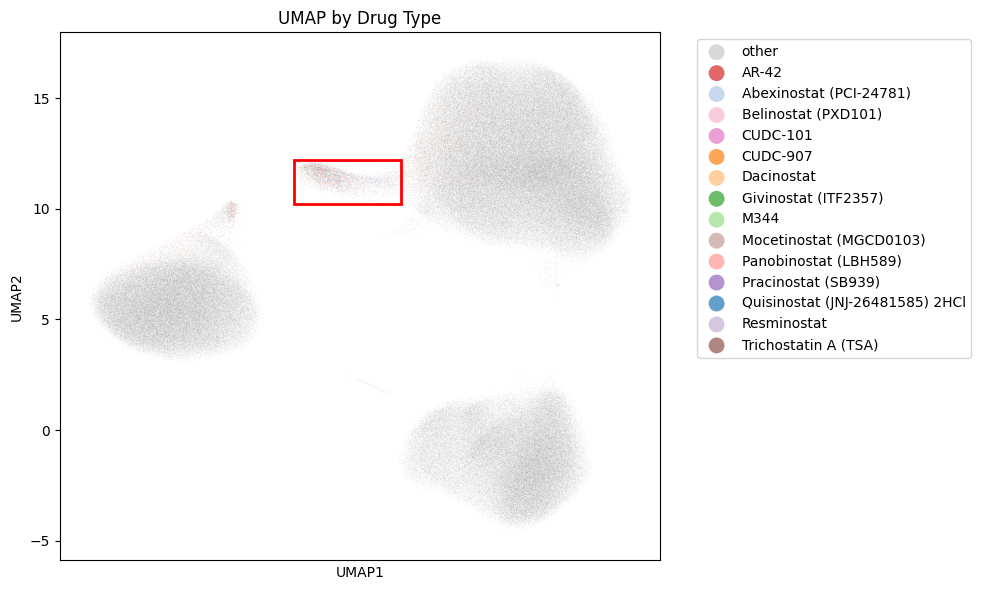

In [13]:
adata = adata_
umap_coords = adata.obsm['X_umap']
umap_x = umap_coords[:, 0]  # UMAP1
umap_y = umap_coords[:, 1]  # UMAP2

cell_types = adata.obs['product_name']

unique_types = np.unique(cell_types)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
color_map = {ct: colors[i] for i, ct in enumerate(unique_types)}
size = 120000 / adata.shape[0]
print( size)

plt.figure(figsize=(10,6))
labeled = False
for i, ct in enumerate(unique_types):
    mask = cell_types == ct
    if ct in non_selected_count_list:
        if not labeled:
            plt.scatter(umap_x[mask], umap_y[mask],
                   c='gray', s=size, label='Other',alpha=0.3,marker='.',edgecolor='none')
            labeled = True
        else:
            plt.scatter(umap_x[mask], umap_y[mask],
                   c='gray', s=size, alpha=0.3,marker='.',edgecolor='none')
    else:
        try:
            plt.scatter(umap_x[mask], umap_y[mask],
                       color=global_color_map[ct], label=ct, s=size, alpha=0.7,marker='.',edgecolor='none')
        except:
            pass
from matplotlib.patches import Rectangle
rectangle = Rectangle((2, 10.2), 4, 2,  # (x, y, width, height)
                     linewidth=2,
                     edgecolor='red',
                     facecolor='none',
                     linestyle='-')
plt.gca().add_patch(rectangle)
plt.xticks([])
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('UMAP by Drug Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',markerscale=50)  # 放大图例中的点)
plt.tight_layout()
plt.show()


1


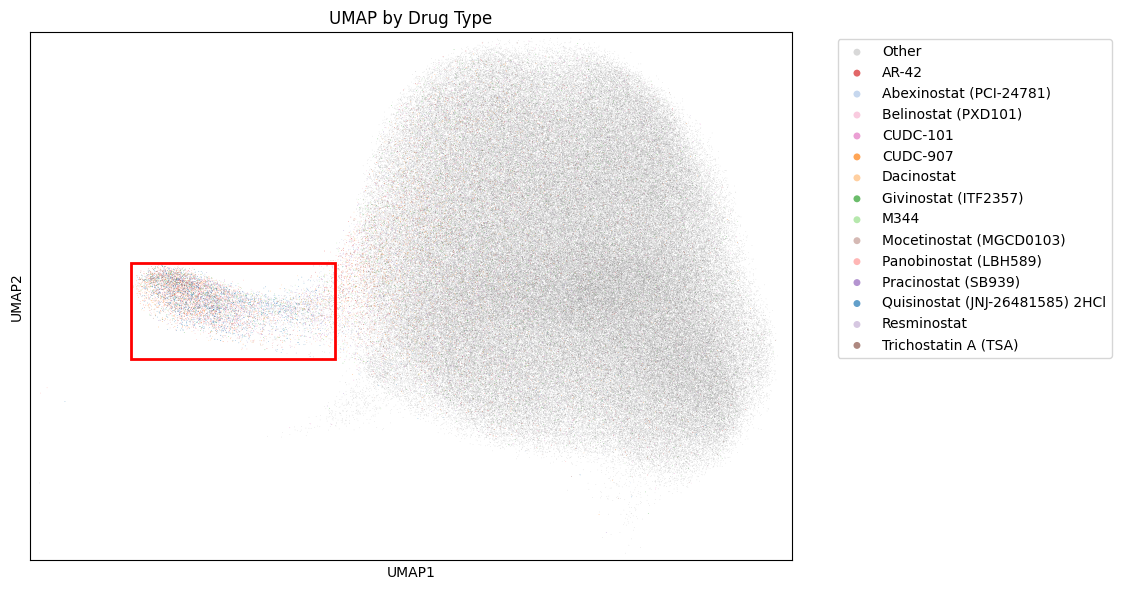

In [19]:
adata = adata_[adata_.obs['cell_type']=='MCF7']
umap_coords = adata.obsm['X_umap']
umap_x = umap_coords[:, 0]  # UMAP1
umap_y = umap_coords[:, 1]  # UMAP2

cell_types = adata.obs['product_name']


unique_types = np.unique(cell_types)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
color_map = {ct: colors[i] for i, ct in enumerate(unique_types)}
size = 1
print( size)

plt.figure(figsize=(12,6))
labeled = False
for i, ct in enumerate(unique_types):
    mask = cell_types == ct
    if ct in non_selected_count_list:
        if not labeled:
            plt.scatter(umap_x[mask], umap_y[mask],
                   c='gray', s=size, label='Other',alpha=0.3,marker='.',edgecolor='none')
            labeled = True
        else:
            plt.scatter(umap_x[mask], umap_y[mask],
                   c='gray', s=size, alpha=0.3,marker='.',edgecolor='none')
    else:
        try:
            plt.scatter(umap_x[mask], umap_y[mask],
                       color=global_color_map[ct], label=ct, s=size, alpha=0.7,marker='.',edgecolor='none')
        except:
            pass
from matplotlib.patches import Rectangle
rectangle = Rectangle((2, 10.2), 4, 2,  # (x, y, width, height)
                     linewidth=2,
                     edgecolor='red',
                     facecolor='none',
                     linestyle='-')
plt.gca().add_patch(rectangle)

x_min = 0
x_max = 15
y_min = 6
y_max = 17

plt.xticks([])
plt.yticks([])
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max) 
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('UMAP by Drug Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',markerscale=10)
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig('Drug_UMAP_Distribution.png', dpi=300)
plt.show()